In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix

# =====================================================
# FINAL TUNED MOBILENET CODE (BEST CHANCE FOR 90%+)
# =====================================================

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS_1 = 12      # initial training
EPOCHS_2 = 4       # fine tuning

TRAIN_DIR = "archive/Training"
VAL_DIR = "archive/Testing"

# =====================================================
# DATA GENERATOR
# =====================================================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=12,
    zoom_range=0.08,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.95, 1.05]
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =====================================================
# CLASS NAMES
# =====================================================
class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

# =====================================================
# BASE MODEL
# =====================================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# =====================================================
# BUILD MODEL
# =====================================================
model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(4, activation='softmax')
])

# =====================================================
# COMPILE PHASE 1
# =====================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# =====================================================
# CALLBACKS
# =====================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        verbose=1
    )
]

# =====================================================
# TRAIN PHASE 1
# =====================================================
print("\n===== PHASE 1 TRAINING =====")

model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_1,
    callbacks=callbacks
)

# =====================================================
# PHASE 2 - FINE TUNE TOP LAYERS
# =====================================================
print("\n===== PHASE 2 FINE TUNING =====")

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_2,
    callbacks=callbacks
)

# =====================================================
# FINAL EVALUATION
# =====================================================
print("\n===== FINAL EVALUATION =====")

test_loss, test_acc = model.evaluate(val_data)
print(f"Final Accuracy: {test_acc*100:.2f}%")

# =====================================================
# REPORTS
# =====================================================
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred_classes))

# =====================================================
# SAVE MODEL
# =====================================================
model.save("brain_tumor_best_model.keras")
print("Model Saved!")


Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']



===== PHASE 1 TRAINING =====
Epoch 1/12


350/350 [==============================] - 87s 243ms/step - loss: 0.9677 - accuracy: 0.6593 - val_loss: 0.8291 - val_accuracy: 0.7556 - lr: 1.0000e-04
Epoch 2/12
350/350 [==============================] - 88s 252ms/step - loss: 0.7211 - accuracy: 0.8209 - val_loss: 0.7785 - val_accuracy: 0.7887 - lr: 1.0000e-04
Epoch 3/12
350/350 [==============================] - 92s 262ms/step - loss: 0.6707 - accuracy: 0.8541 - val_loss: 0.7425 - val_accuracy: 0.8012 - lr: 1.0000e-04
Epoch 4/12
350/350 [==============================] - 92s 263ms/step - loss: 0.6457 - accuracy: 0.8648 - val_loss: 0.7449 - val_accuracy: 0.8106 - lr: 1.0000e-04
Epoch 5/12
350/350 [==============================] - 85s 243ms/step - loss: 0.6189 - accuracy: 0.8789 - val_loss: 0.7059 - val_accuracy: 0.8213 - lr: 1.0000e-04
Epoch 6/12
35

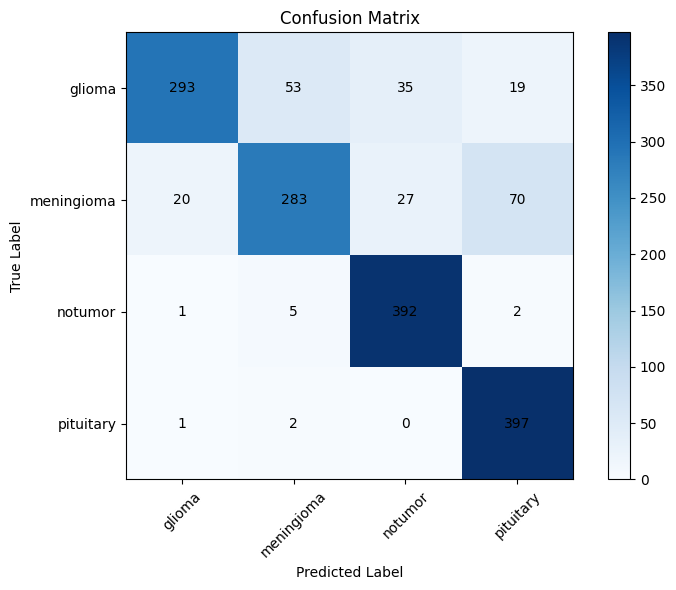

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

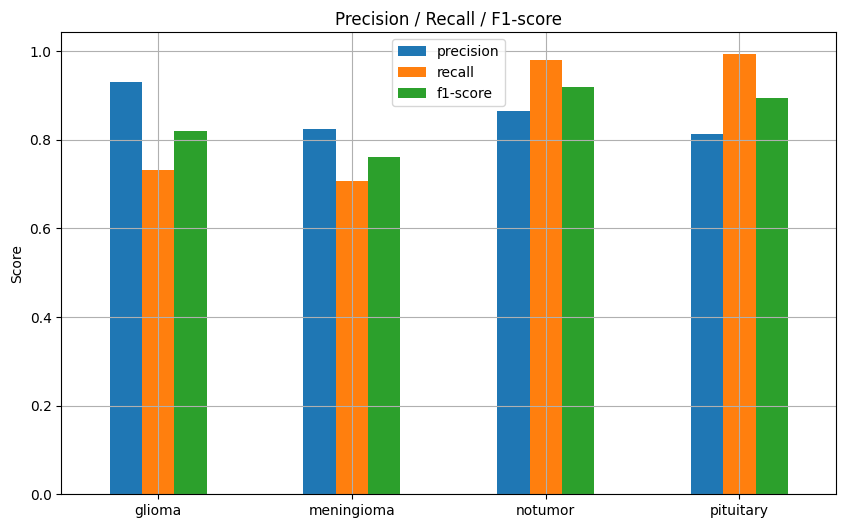

In [3]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

df = pd.DataFrame(report).transpose()
df = df.iloc[:4, :3]

df.plot(kind='bar', figsize=(10,6))
plt.title("Precision / Recall / F1-score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

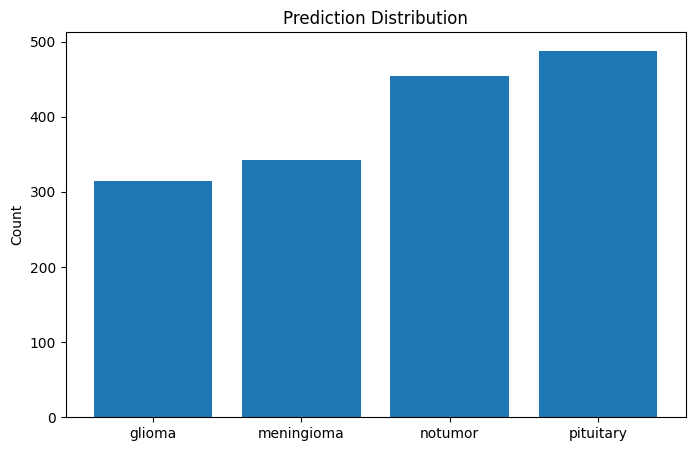

In [4]:
pred_counts = np.bincount(y_pred_classes)

plt.figure(figsize=(8,5))
plt.bar(class_names, pred_counts)
plt.title("Prediction Distribution")
plt.ylabel("Count")
plt.show()